# exp_ana_gis

## 0. 开头与公共准备

### 0.1 Notebook 目标与结构说明
本 notebook 以 `研究框架.md` 的附录 C 与附录 D 为统一参照，把参考实验重新整理为 `GIS` 主线。整个实验按照“微观建模 -> 宏观构造 -> 宏微比较 -> CE 计算”的顺序展开，并进一步加入 `step2` 系统下的 SVD / EVD 对比。

### 0.2 公共依赖、绘图风格与统一参数
这一块负责导入依赖、定位仓库根目录、设置绘图风格，并统一默认参数。后续默认采用
$$
\tau = 1, \qquad \alpha = 1,
$$
噪声默认取高斯噪声，热力图统一使用 `vlag` 色图。这样后面每一部分只需要改少量参数，就可以复用同一套分析函数。


In [3]:
import sys
from pathlib import Path
REPO_ROOT = None
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (candidate / 'tools.py').exists():
        REPO_ROOT = candidate
        break
if REPO_ROOT is None:
    raise RuntimeError('Could not locate repository root containing tools/tools.py')
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap
import seaborn as sns
from IPython.display import display

from tools import (
    make_step_system_matrix, step_map, observable_step, observable_step2,
    simulate_discrete_system, add_gaussian_noise, prepare_time_pairs,
    fit_linear_gis_from_pairs, fit_linear_gis_from_matrix,
    compute_gis_metrics, compute_prediction_errors, compute_ce_from_micro_macro,
    select_macro_rank, build_w_from_svd, build_w_from_evd,
    apply_coarse_graining, summarize_pipeline_results, compute_gamma_ce_metrics,
    estimate_covariance_from_residuals,plot_dual_gis_spectrum,plot_gis_spectrum
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 160
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Noto Sans CJK SC', 'DejaVu Sans']
HEATMAP_CMAP = 'vlag'
DEFAULT_CONFIG = {'tau': 1, 'delta': None, 'alpha': 1.0, 'noise_scale': 0.05, 'eps': 1e-10, 'ridge': 1e-10, 'manual_r': 1}
DEFAULT_CONFIG


{'tau': 1,
 'delta': None,
 'alpha': 1.0,
 'noise_scale': 0.05,
 'eps': 1e-10,
 'ridge': 1e-10,
 'manual_r': 1}

### 0.3 公共函数区（本实验特有的，不包括复用 `tools.py` 里面的函数）
这里集中定义 notebook 自己用到的辅助函数，主要做三件事：

1. 统一绘图风格，例如矩阵热力图、奇异值谱和标准化曲线；
2. 支撑第一部分的参数扫描与谱图展示；
3. 把附录 D 的主流程打包成一个可以重复调用的实验函数。

其中最核心的包装逻辑是
$$
\mathbf{o}_t \rightarrow (A_o,\Sigma_o) \rightarrow W \rightarrow \mathbf{z}_t \rightarrow (A_z,\Sigma_z) \rightarrow CE,
$$
这样第三部分和第四部分就可以共享同一套流程。


In [ ]:
def sparse_labels(labels, step=1):
    if labels is None:
        return False
    if step <= 1:
        return labels
    return [label if i % step == 0 else '' for i, label in enumerate(labels)]

def plot_matrix_heatmap(matrix, title, row_labels=None, col_labels=None, center=0.0, figsize=(6, 6), label_step=1, cmap=HEATMAP_CMAP):
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(np.asarray(matrix), ax=ax, cmap=cmap, center=center, square=np.asarray(matrix).shape[0]==np.asarray(matrix).shape[1], xticklabels=sparse_labels(col_labels, label_step), yticklabels=sparse_labels(row_labels, label_step))
    ax.set_title(title)
    plt.tight_layout(); plt.show()

def standardize_for_plot(x):
    x = np.asarray(x, dtype=float)
    return (x - np.mean(x)) / (np.std(x) + 1e-12)

def generate_parameter_scan_results(lam_values=None, log_min=-4, log_max=4, n_points=120):
    if lam_values is None:
        lam_values = [0.0001,0.0002,0.0005,0.001,0.002,0.005,0.01,0.02,0.05,0.1,0.2,0.5,1.0]
    ratios = 10 ** np.linspace(log_min, log_max, n_points)
    results = {}
    for lam in lam_values:
        results[lam] = {'ratios': ratios, 'sv1': [], 'sv2': [], 'sv3': []}
        for ratio in ratios:
            mu = lam / ratio
            sv = np.sort(np.linalg.svd(make_step_system_matrix(lam, mu), compute_uv=False))[::-1]
            results[lam]['sv1'].append(sv[0]); results[lam]['sv2'].append(sv[1]); results[lam]['sv3'].append(sv[2])
    return results, lam_values, ratios

def plot_singular_values_boxplot(results, lam_values, ratios):
    rows = []
    for lam in lam_values:
        for i, ratio in enumerate(ratios):
            lbl = f"$10^{{{np.log10(ratio):.0f}}}$"
            rows += [
                {'Ratio': lbl, 'Singular Value': results[lam]['sv1'][i], 'Type': '$\sigma_1$'},
                {'Ratio': lbl, 'Singular Value': results[lam]['sv2'][i], 'Type': '$\sigma_2$'},
                {'Ratio': lbl, 'Singular Value': results[lam]['sv3'][i], 'Type': '$\sigma_3$'},
            ]
    df = pd.DataFrame(rows)
    plt.figure(figsize=(7, 5))
    sns.boxplot(data=df, x='Ratio', y='Singular Value', hue='Type', palette='Set2')
    plt.yscale('log'); plt.xlabel('$\lambda / \mu$ ratio'); plt.ylabel('Singular value'); plt.tight_layout(); plt.show()

def project_matrix_with_w(A, Sigma, W):
    return W @ A @ W.T, W @ Sigma @ W.T

def run_gis_pipeline_from_observations(observations, tau=1, alpha=1.0, delta=None, eps=1e-10, ridge=1e-10, manual_r=1, horizons=(1,3,5), w_method='svd', evd_mode='eig_abs'):
    X_now, X_next = prepare_time_pairs(observations, tau=tau, burn_in=0, stride=1)
    micro_fit = fit_linear_gis_from_pairs(X_now, X_next, fit_intercept=False, ridge=ridge, regularization=eps)
    micro_metrics = compute_gis_metrics(micro_fit['A'], micro_fit['Sigma'], alpha=alpha, eps=eps)
    micro_errors = compute_prediction_errors(micro_fit['A'], observations, tau=tau, horizons=horizons)
    rank_values = micro_metrics['sv_backward'] if w_method == 'svd' else np.abs(np.linalg.eigvals(micro_fit['A']))
    r, rank_meta = select_macro_rank(rank_values, mode='manual', manual_r=manual_r, eps=eps)
    w_result = build_w_from_svd(micro_fit['A'], micro_fit['Sigma'], r=r, alpha=alpha, eps=eps, mode='two_stage') if w_method == 'svd' else build_w_from_evd(micro_fit['A'], r=r, mode=evd_mode)
    W = w_result['W']
    macro_observations = apply_coarse_graining(W, observations)
    Z_now, Z_next = prepare_time_pairs(macro_observations, tau=tau, burn_in=0, stride=1)
    macro_fit = fit_linear_gis_from_pairs(Z_now, Z_next, fit_intercept=False, ridge=ridge, regularization=eps)
    macro_metrics = compute_gis_metrics(macro_fit['A'], macro_fit['Sigma'], alpha=alpha, eps=eps)
    macro_errors = compute_prediction_errors(macro_fit['A'], macro_observations, tau=tau, horizons=horizons)
    ce_result = compute_ce_from_micro_macro(micro_metrics, macro_metrics)
    summary_dict, summary_row = summarize_pipeline_results(
        config={'tau': tau, 'delta': delta, 'alpha': alpha, 'w_method': w_method, 'manual_r': manual_r},
        micro_fit=micro_fit, macro_fit=macro_fit, micro_metrics=micro_metrics, macro_metrics=macro_metrics,
        prediction_results={'micro_errors': micro_errors, 'macro_errors': macro_errors}, ce_result=ce_result,
        extra={'rank_meta': rank_meta, 'w_result': w_result},
    )
    return {'micro_fit': micro_fit, 'micro_metrics': micro_metrics, 'micro_errors': micro_errors, 'rank_meta': rank_meta, 'w_result': w_result, 'W': W, 'macro_observations': macro_observations, 'macro_fit': macro_fit, 'macro_metrics': macro_metrics, 'macro_errors': macro_errors, 'ce_result': ce_result, 'summary_dict': summary_dict, 'summary_row': summary_row}

## 第一部分：参数影响实验

### 1.1 第一类系统与本部分目标
本部分研究的第一类系统为
$$
\begin{aligned}
x_{k+1} &= \lambda x_k,\\
y_{k+1} &= \mu y_k + (\lambda^2 - \mu) x_k^2.
\end{aligned}
$$
在观测函数
$$
g(x,y)=[x,\;y,\;x^2]^\top
$$
下，其观测层解析矩阵可以直接写出。这里暂时不走完整 `GIS` 流程，而是先观察不同参数下奇异值谱是否出现明显分离。

### 1.2 解析矩阵与参数扫描设定
下面对一组 $\lambda$ 取值和一组 $\lambda / \mu$ 比例进行扫描，并绘制奇异值谱的箱型图。若谱之间出现明显断层，后续粗粒化往往更容易提取出稳定的低维宏观方向。


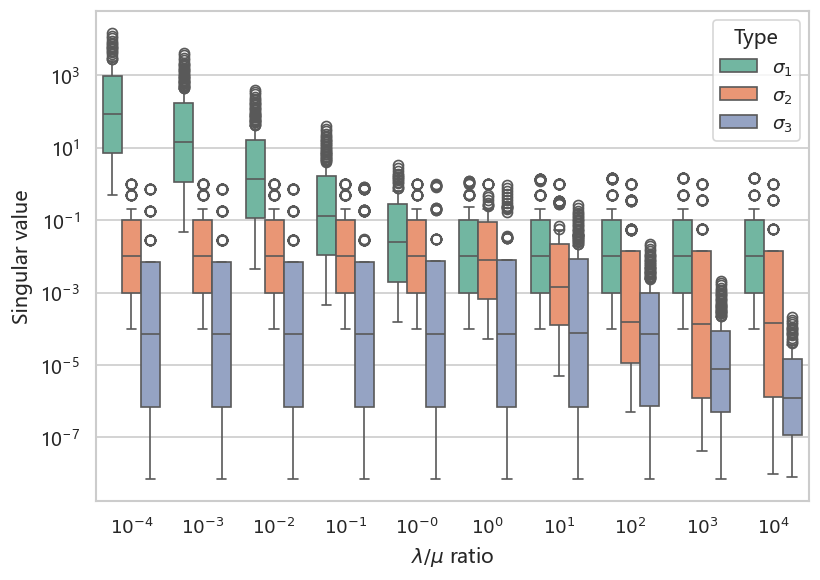

In [5]:
scan_results, scan_lam_values, scan_ratios = generate_parameter_scan_results()
plot_singular_values_boxplot(scan_results, scan_lam_values, scan_ratios)


### 1.2 参数扫描结果的补充说明
箱型图提供的是整体分布信息。为了更具体地看清某一组参数下矩阵本身的尺度关系，下面补充展示一组代表性参数对应的解析矩阵奇异值。这样后面看宏观维度选择时，会更容易理解为什么某些维度会被保留下来。


In [6]:
example_lam, example_mu = 0.1, 0.9
example_A = make_step_system_matrix(example_lam, example_mu)
example_sv = np.sort(np.linalg.svd(example_A, compute_uv=False))[::-1]
display(pd.DataFrame({'singular_index': [1, 2, 3], 'singular_value': example_sv}))


,singular_index,singular_value
0,1,1.26576
1,2,0.10000
2,3,0.00711


### 1.3 固定参数下的轨迹相图
下面固定一组代表性参数，从多个初值出发生成轨迹，并在相空间中画出渐变轨迹。这个图的作用主要是帮助直观理解系统在状态空间中的收缩路径与组织方式，也为后面解释低维主方向提供几何背景。


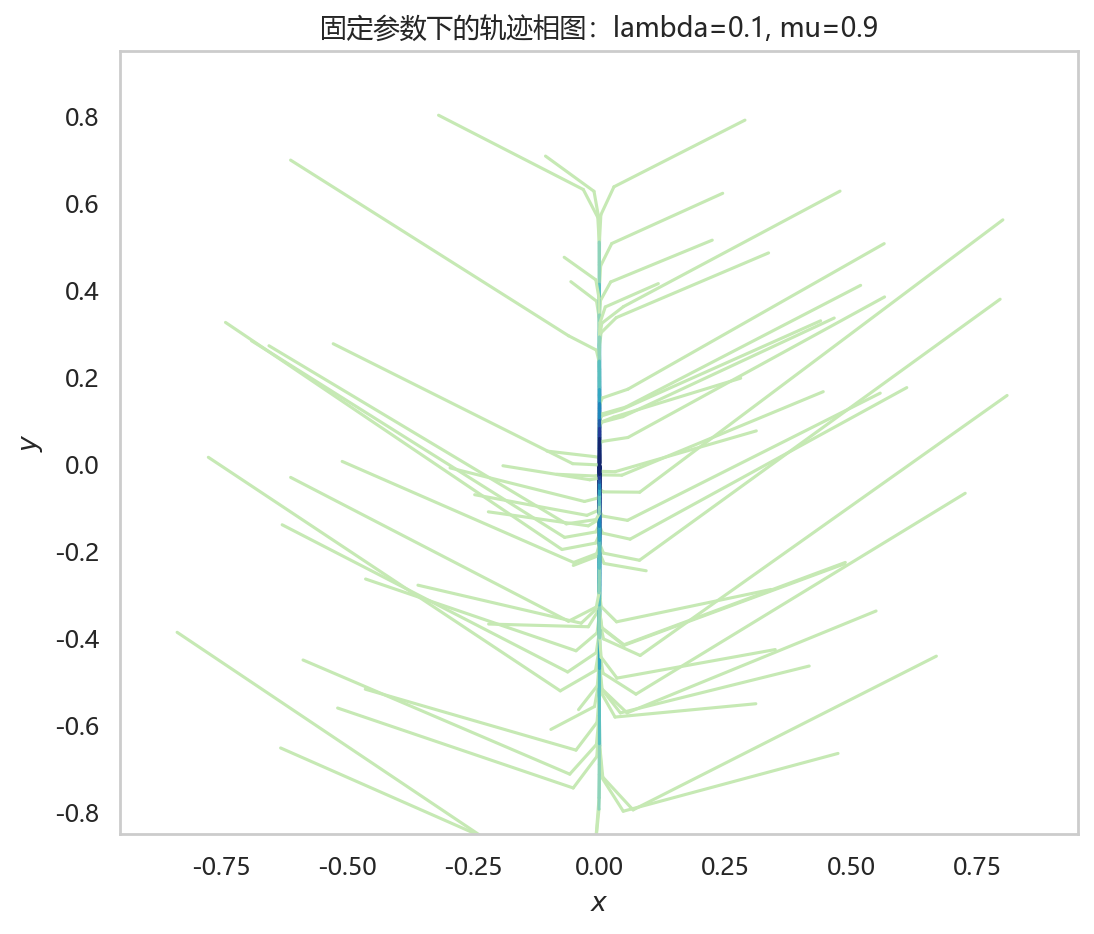

In [7]:
phase_lam, phase_mu, phase_steps, num_samples = 0.1, 0.9, 50, 60
rng = np.random.default_rng(42)
initial_points = np.vstack([rng.uniform(-0.85, 0.85, num_samples), rng.uniform(-0.7, 0.85, num_samples)]).T
fig, ax = plt.subplots(figsize=(7, 6), dpi=160)
custom_cmap = ListedColormap(plt.cm.YlGnBu(np.linspace(0.25, 0.95, 8)))
for x0, y0 in initial_points:
    traj = simulate_discrete_system(step_map, [x0, y0], steps=phase_steps, system_kwargs={'lam': phase_lam, 'mu': phase_mu}, dt=1.0)['trajectories'][0]
    points = traj.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    color_idx = np.arange(len(segments)); color_idx[np.where(color_idx > 20)] = 20
    lc = LineCollection(segments, cmap=custom_cmap); lc.set_array(color_idx); lc.set_linewidth(1.4); lc.set_capstyle('round'); ax.add_collection(lc)
ax.set_title(f'固定参数下的轨迹相图：lambda={phase_lam}, mu={phase_mu}')
ax.set_xlabel('$x$'); ax.set_ylabel('$y$'); ax.set_xlim([-0.95, 0.95]); ax.set_ylim([-0.85, 0.95]); ax.grid(False); plt.tight_layout(); plt.show()


## 第二部分：已知解析矩阵 A / K_raw 的矩阵分析

### 2.1 本部分的目标与和主流程的关系
本部分不从数据出发，而是直接给定解析矩阵 `A`。我们把它视为观测层微观 `GIS` 的动力学矩阵，并在近零噪声条件下单独分析矩阵本身。这样可以把“矩阵结构的贡献”和“数据拟合误差的影响”分开来看。

### 2.2 给定解析矩阵与无噪声设定
这里固定参数后直接构造解析矩阵 `A`，并把噪声协方差设为近零对角形式。换句话说，这一部分等价于已知
$$
\mathbf{o}_{t+\tau} \approx A_o \mathbf{o}_t + \varepsilon_t^{(o)}, \qquad \Sigma_o \approx 0,
$$
只不过为了数值稳定，协方差矩阵会保留一个很小的正则项。


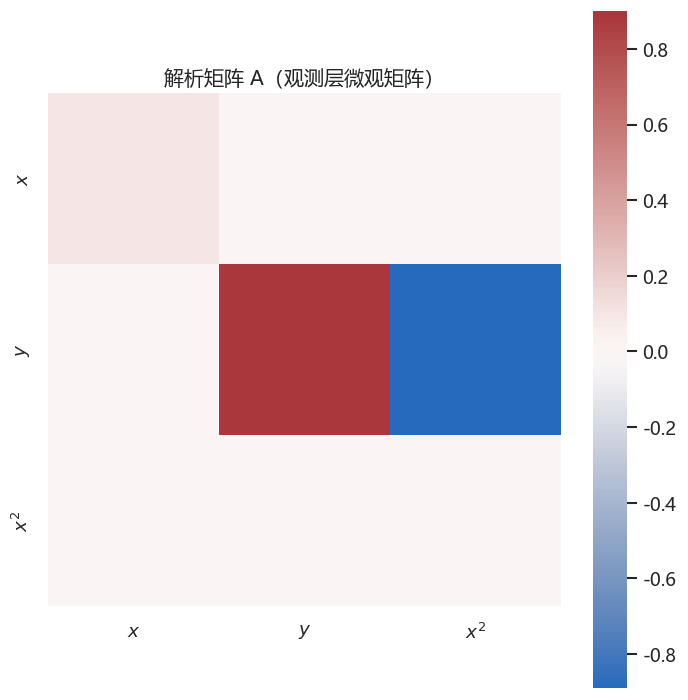

In [8]:
direct_config = {'lam': 0.1, 'mu': 0.9, 'alpha': 1.0, 'eps': 1e-10, 'manual_r': 1}
direct_feature_names = ['$x$', '$y$', '$x^2$']
A_direct = make_step_system_matrix(direct_config['lam'], direct_config['mu'])
plot_matrix_heatmap(A_direct, '解析矩阵 A（观测层微观矩阵）', row_labels=direct_feature_names, col_labels=direct_feature_names, label_step=1)


### 2.3 已知确定动力学微观层奇异值分析
这一部分不再使用 `GIS(A, \Sigma)` 的流程，因为此时我们并没有从数据残差中估计噪声协方差矩阵。这里直接把解析矩阵 `A / K_{raw}` 当作一个确定性的线性动力学矩阵，对它本身做奇异值分解：
$$
A = U \Sigma_A V^\top.
$$
下面先输出解析矩阵的奇异值，并把左奇异向量 `U` 作为后续粗粒化的候选方向。


,singular_index,singular_value
0,1,1.26576
1,2,0.10000
2,3,0.00711


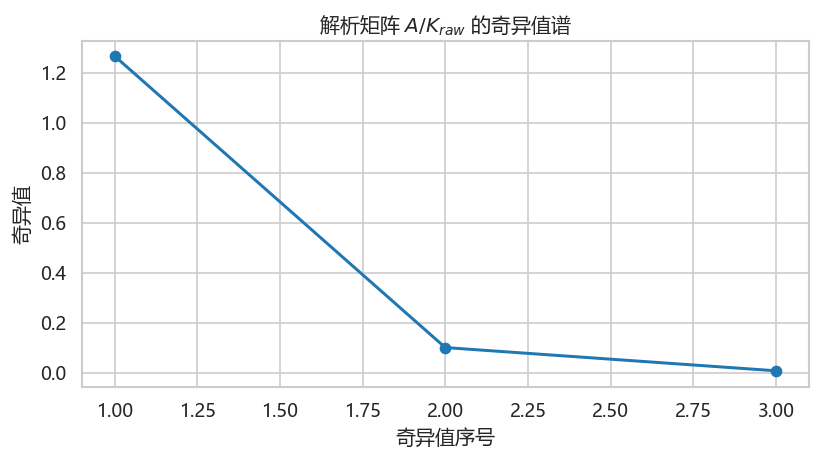

In [9]:
direct_U, direct_S, direct_Vt = np.linalg.svd(A_direct, full_matrices=False)
direct_gamma = compute_gamma_ce_metrics(direct_S, alpha=direct_config['alpha'], manual_r=direct_config['manual_r'], eps=direct_config['eps'])
display(pd.DataFrame({'singular_index': np.arange(1, len(direct_S) + 1), 'singular_value': direct_S}))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, len(direct_S) + 1), direct_S, marker='o', color='tab:blue', linewidth=1.8)
ax.set_title('解析矩阵 $A/K_{raw}$ 的奇异值谱')
ax.set_xlabel('奇异值序号')
ax.set_ylabel('奇异值')
plt.tight_layout(); plt.show()


### 2.4 宏观维度选择与粗粒化矩阵构造
根据奇异值谱指定或选择宏观维度 `r`，然后用前 `r` 个左奇异向量构造粗粒化矩阵。若
$$
A = U \Sigma_A V^\top,
$$
则线性粗粒化矩阵取为
$$
W = U_r^\top,
\qquad
U_r = U[:, :r].
$$
在当前实验里默认取 `r=1`。


选定的宏观维度 r = 1


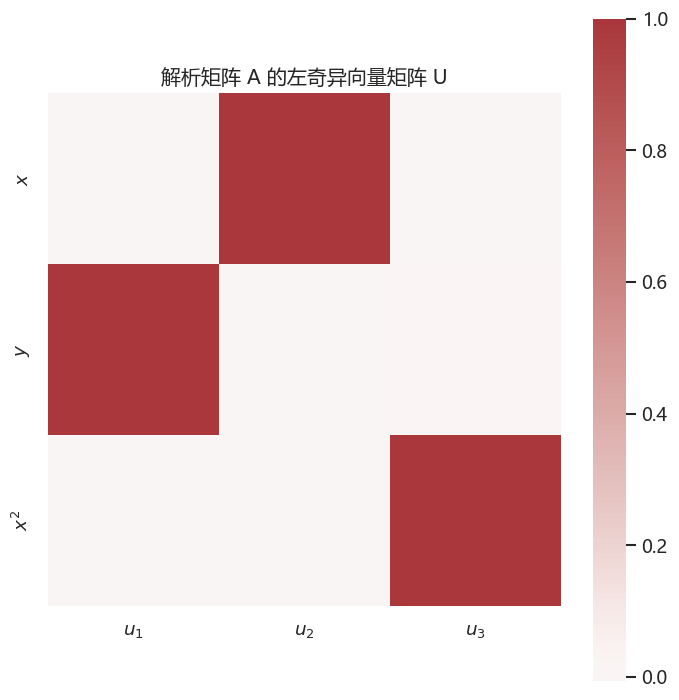

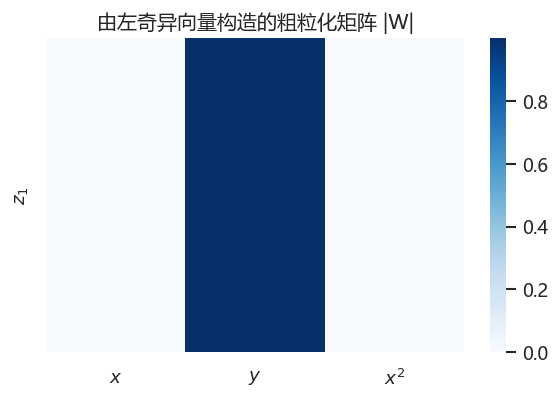

In [10]:
direct_r = int(direct_config['manual_r'])
direct_left_basis = direct_U[:, :direct_r]
W_direct = direct_left_basis.T
print('选定的宏观维度 r =', direct_r)
plot_matrix_heatmap(direct_U, '解析矩阵 A 的左奇异向量矩阵 U', row_labels=direct_feature_names, col_labels=[f'$u_{i+1}$' for i in range(direct_U.shape[1])], label_step=1)
plot_matrix_heatmap(np.abs(W_direct), '由左奇异向量构造的粗粒化矩阵 |W|', row_labels=[f'$z_{i+1}$' for i in range(direct_r)], col_labels=direct_feature_names, center=None, figsize=(5, 3.5), cmap='Blues')


### 2.5 宏观层矩阵分析
在确定 `W` 之后，直接把解析矩阵投影到宏观层：
$$
A_z = W A W^\top.
$$
由于这一部分是确定性矩阵分析，所以这里关注的是投影后的宏观矩阵本身，以及它的奇异值结构是否更集中。


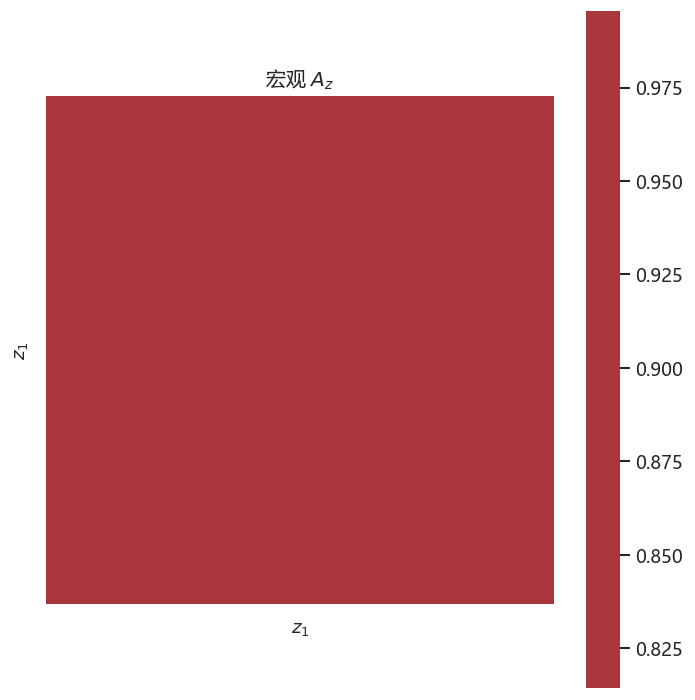

In [11]:
A_direct_macro = W_direct @ A_direct @ W_direct.T
macro_names_direct = [f'$z_{i+1}$' for i in range(direct_r)]
plot_matrix_heatmap(A_direct_macro, '宏观 $A_z$', row_labels=macro_names_direct, col_labels=macro_names_direct, label_step=1)


### 2.6 宏观层奇异值分析
宏观层同样直接对 `A_z` 做奇异值分解。这样第二部分的比较逻辑就是：先看原始解析矩阵 `A` 的奇异值谱，再看由左奇异向量粗粒化后得到的宏观矩阵 `A_z` 的奇异值谱，从而判断主要动力学方向是否被压缩并保留下来。


,singular_index,singular_value
0,1,0.904917


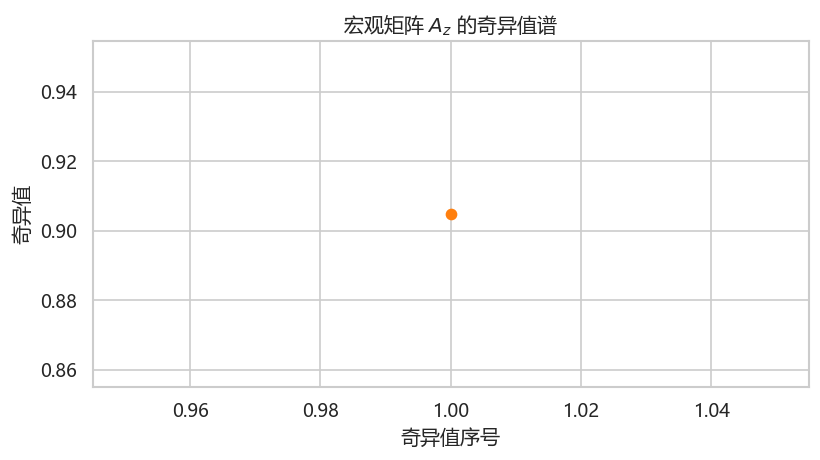

In [12]:
direct_macro_U, direct_macro_S, direct_macro_Vt = np.linalg.svd(A_direct_macro, full_matrices=False)
display(pd.DataFrame({'singular_index': np.arange(1, len(direct_macro_S) + 1), 'singular_value': direct_macro_S}))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, len(direct_macro_S) + 1), direct_macro_S, marker='o', color='tab:orange', linewidth=1.8)
ax.set_title('宏观矩阵 $A_z$ 的奇异值谱')
ax.set_xlabel('奇异值序号')
ax.set_ylabel('奇异值')
plt.tight_layout(); plt.show()


### 2.7 CE：基于解析矩阵奇异值谱的宏观增益
直接根据解析矩阵奇异值谱计算通道平均增益偏差。也就是说，先对奇异值做  $\sigma_i^\alpha$  变换，再比较截取前 `r` 个主通道后的平均值与整体平均值之差。该量可以视作确定性解析矩阵下的“谱驱动宏观增益”。


In [13]:
direct_ce = {
    'CE': direct_gamma['delta_gamma_manual_r'],
    'selected_r': direct_gamma['selected_r'],
    'delta_gamma_selected_r': direct_gamma['delta_gamma_selected_r'],
    'Gamma_alpha_K': direct_gamma['Gamma_alpha_K'],
    'gamma_alpha_K': direct_gamma['gamma_alpha_K'],
}
display(pd.DataFrame({
    'quantity': ['Gamma_alpha_K', 'gamma_alpha_K', 'selected_r', 'delta_gamma_selected_r', 'manual_r', 'direct_CE'],
    'value': [direct_gamma['Gamma_alpha_K'], direct_gamma['gamma_alpha_K'], direct_gamma['selected_r'], direct_gamma['delta_gamma_selected_r'], direct_gamma['manual_r'], direct_gamma['delta_gamma_manual_r']]
}))
print('第二部分的谱驱动 CE =', direct_ce['CE'])


,quantity,value
0,Gamma_alpha_K,1.372871
1,gamma_alpha_K,0.457624
2,selected_r,1.000000
3,delta_gamma_selected_r,0.808137
4,manual_r,1.000000
5,direct_CE,0.808137


第二部分的谱驱动 CE = 0.8081368304445518


## 第三部分：含噪实验

### 3.1 本部分目标与主流程说明
已知动力学与已知噪声模型的方法验证:在已知真值 $A$ 与真值 $\Sigma$ 的条件下，检验当前 `GIS` 宏微观分析流程是否能够给出合理的宏观表示与正的 `CE`。

因此，本部分中：
$$
o_{t+\tau} = A o_t + \varepsilon_t,
\qquad
\varepsilon_t \sim \mathcal{N}(0,\Sigma)
$$
其中：
- $A_o$ 直接由已知动力学给出；
- $\Sigma_o$ 不再通过残差估计，而是直接由观测层噪音样本计算得到。数据在这里主要承担展示和验证作用，而不再承担识别 $A,\Sigma$ 的任务。


### 3.2 数据生成、原始噪音与观测层噪音

先由已知动力学生成干净原始轨迹 $x_t$，再在原始状态层加入人为设定的高斯噪音，得到带噪原始轨迹。也就是说，噪音首先加在原始数据层，而不是直接加在观测层。

设原始状态层的噪音为
$$
\eta_t \sim \mathcal{N}(0,\Sigma_x),
$$
则带噪原始状态写为
$$
x_t^{\text{noisy}} = x_t^{\text{clean}} + \eta_t.
$$

由于后续 `GIS` 分析是在观测层进行的，因此真正需要的协方差矩阵不是原始状态层的噪音协方差，而是观测层的有效噪音协方差。为此，需要同时计算干净观测层数据与带噪观测层数据，并用它们的差来定义观测层噪音。



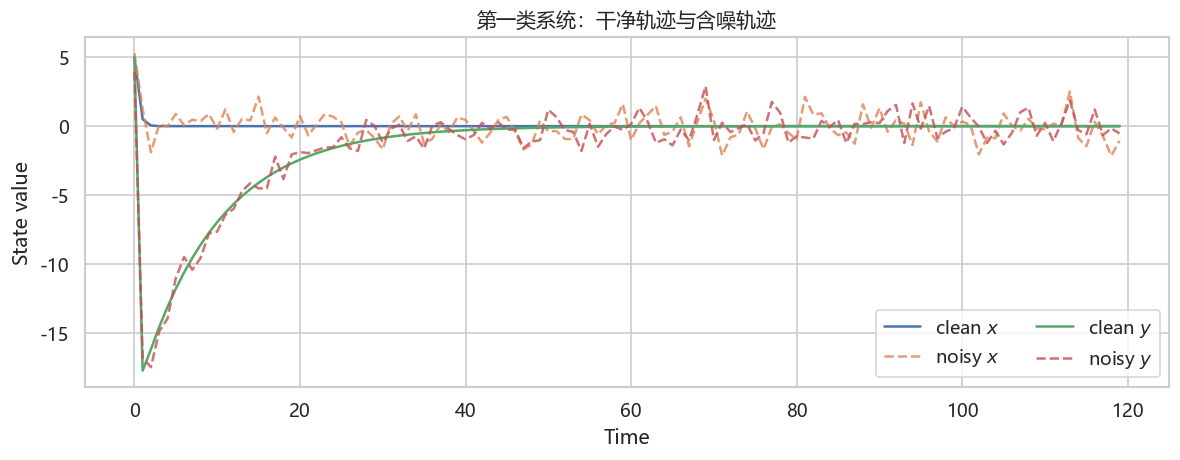

In [43]:
analysis_config = {
    'experiment_name': 'exp_ana_gis_part3', 'lam': 0.1, 'mu': 0.9, 'initial_state': [5.0, 5.0], 'steps': 600, 'dt': 1.0, 'tau': 1, 'delta': None, 
    'alpha': 1.0, 'noise_scale': 1, 'noise_seed': 42, 'eps': 1e-10, 'ridge': 1e-10, 'manual_r': 1, 'horizons': (1, 3, 5)}
clean_sim = simulate_discrete_system(step_map, analysis_config['initial_state'], steps=analysis_config['steps'], system_kwargs={'lam': analysis_config['lam'], 'mu': analysis_config['mu']}, dt=analysis_config['dt'])
clean_xy = clean_sim['trajectories'][0]; time_grid = clean_sim['time_grid']
noisy_xy = add_gaussian_noise(clean_xy, noise_scale=analysis_config['noise_scale'], cov=None, random_state=analysis_config['noise_seed'])['noisy_data']
plt.figure(figsize=(10,4))
plt.plot(time_grid[:120], clean_xy[:120,0], label='clean $x$')
plt.plot(time_grid[:120], noisy_xy[:120,0], '--', alpha=0.8, label='noisy $x$')
plt.plot(time_grid[:120], clean_xy[:120,1], label='clean $y$')
plt.plot(time_grid[:120], noisy_xy[:120,1], '--', alpha=0.8, label='noisy $y$')
plt.title('第一类系统：干净轨迹与含噪轨迹')
plt.xlabel('Time')
plt.ylabel('State value')
plt.legend(ncol=2)
plt.tight_layout(); plt.show()


### 3.3 观测函数、时间尺度与样本配对
这里固定观测函数
$g(x,y)=[x,\;y,\;x^2]^\top,$
并根据时间尺度 $\tau$ 把原始状态映射到观测空间，得到：
- 干净观测层数据 $o_t^{\text{clean}} = g(x_t^{\text{clean}})$
- 带噪观测层数据 $o_t^{\text{noisy}} = g(x_t^{\text{noisy}})$

后续参与预测、宏微观曲线对比和宏观构造的，是带噪观测层数据 $o_t^{\text{noisy}}$；而观测层噪音协方差的计算，则依赖于干净观测层和带噪观测层之间的差异。



In [44]:
obs_clean_part3 = observable_step(clean_xy, mode='default')
obs_part3 = observable_step(noisy_xy, mode='default')
obs_noise3 = obs_part3 - obs_clean_part3
Sigma3_micro = estimate_covariance_from_residuals(obs_noise3, center=True, regularization=analysis_config['eps'])
X_now_3, X_next_3 = prepare_time_pairs(obs_part3, tau=analysis_config['tau'], burn_in=0, stride=1)
feature_names_3 = ['$x$', '$y$', '$x^2$']
print('观测层数据形状:', obs_part3.shape)
print('观测层噪音数据形状:', obs_noise3.shape)
print('配对样本形状:', X_now_3.shape, X_next_3.shape)


观测层数据形状: (601, 3)
观测层噪音数据形状: (601, 3)
配对样本形状: (600, 3) (600, 3)


### 3.4 微观层真值 $A_o$ 与观测层真值协方差 $\Sigma_o$

微观层动力学矩阵直接使用已知真值矩阵 $A_o$，而协方差矩阵则由观测层噪音样本直接计算得到。

先定义观测层噪音为
$$
\varepsilon_t^{(o)} = o_t^{\text{noisy}} - o_t^{\text{clean}}.
$$
然后用它的样本协方差定义
$$
\Sigma_o = \mathrm{Cov}(\varepsilon_t^{(o)}).
$$

因此，本部分采用的是：
$$
A_o = A_{\text{true}},
\qquad
\Sigma_o = \mathrm{Cov}\!\bigl(o_t^{\text{noisy}} - o_t^{\text{clean}}\bigr).
$$

这样做的目的是把参数识别误差从实验中剥离出去，专门验证在真值参数已知条件下，当前方法本身能否恢复合理的宏观结构。


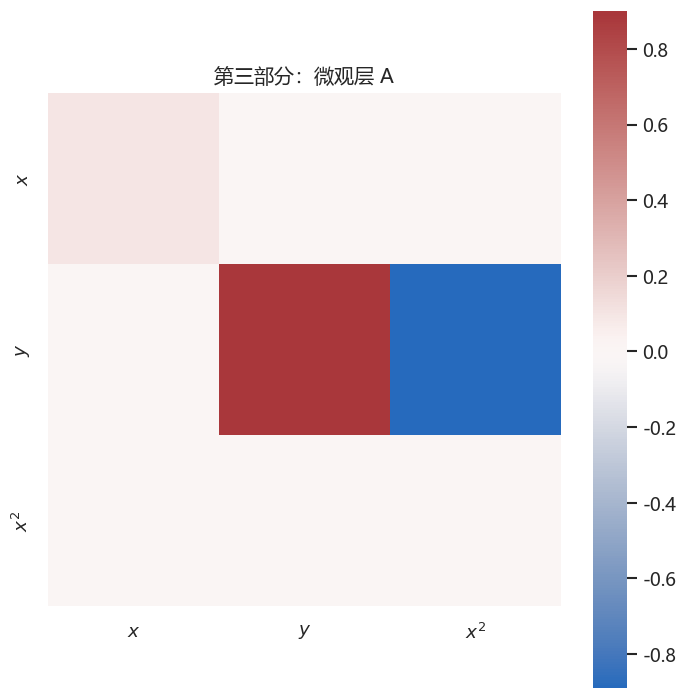

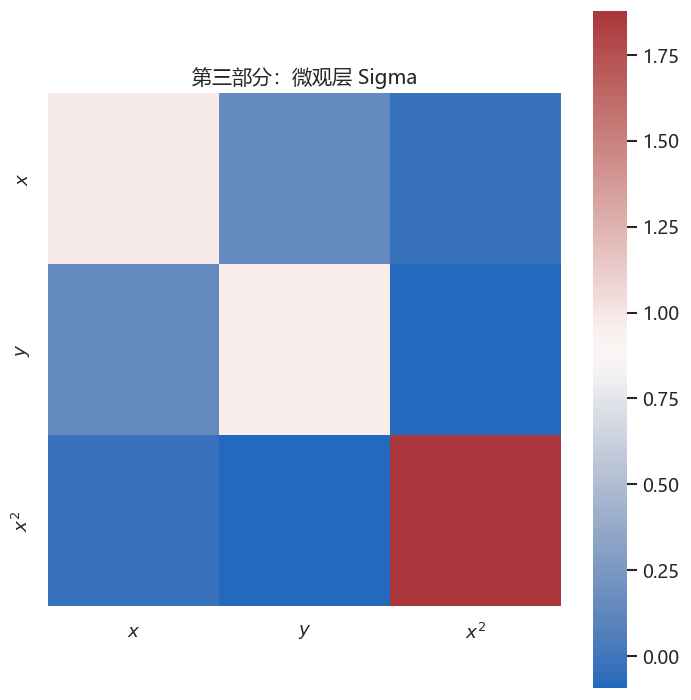

In [45]:
A3_micro = make_step_system_matrix(analysis_config['lam'], analysis_config['mu'])
fit3_micro = {
    'A': A3_micro,
    'Sigma': Sigma3_micro,
    'source': 'known_true_A_and_observation_noise_covariance',
}
plot_matrix_heatmap(A3_micro, '第三部分：微观层 A', row_labels=feature_names_3, col_labels=feature_names_3, label_step=1)
plot_matrix_heatmap(Sigma3_micro, '第三部分：微观层 Sigma', row_labels=feature_names_3, col_labels=feature_names_3, center=None, label_step=1)


### 3.5 微观层预测与误差

在已知真值 $A_o$ 的前提下，仍然可以对带噪观测层数据做单步预测和多步滚动预测：
得到微观层 `A_o` 后，可做单步预测和多步滚动预测：
$$
\hat{\mathbf{o}}_{t+\tau|t}=A_o\mathbf{o}_t,
\qquad
\hat{\mathbf{o}}_{t+k\tau|t}=A_o^k\mathbf{o}_t.
$$
下面先输出一步和多步误差，再把真实曲线与单步预测曲线画在一起，直观看微观层预测是否已经能较好跟住数据。


,horizon,mean_error
0,1,7.882439
1,3,6.900713
2,5,6.146967


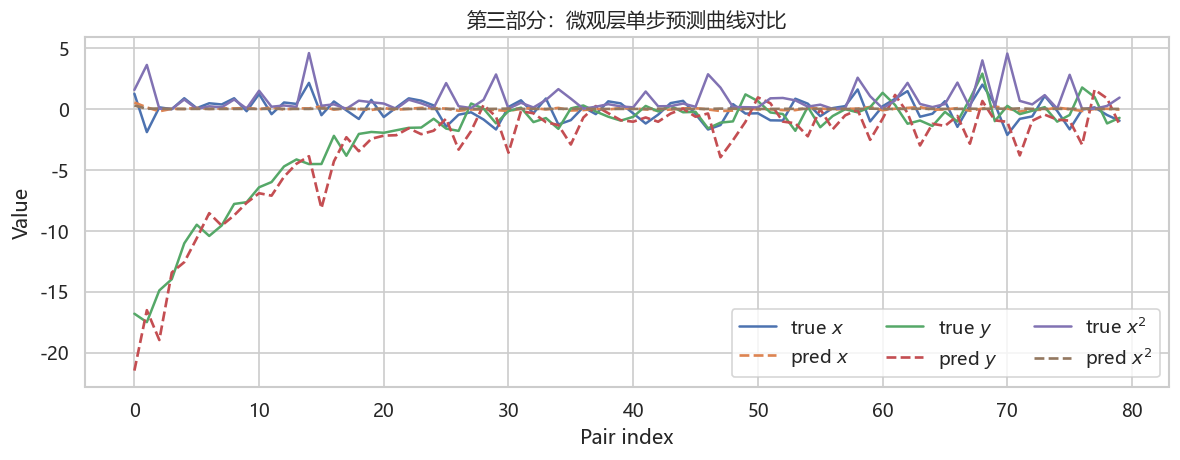

In [46]:
errors3_micro = compute_prediction_errors(A3_micro, obs_part3, tau=analysis_config['tau'], horizons=analysis_config['horizons'])
display(pd.DataFrame({'horizon': list(errors3_micro.keys()), 'mean_error': [errors3_micro[h]['mean_error'] for h in errors3_micro.keys()]}))
pred1_micro, target1_micro = errors3_micro[1]['predictions'], errors3_micro[1]['targets']
plt.figure(figsize=(10,4))
for idx, name in enumerate(feature_names_3):
    plt.plot(np.arange(len(pred1_micro[:80])), target1_micro[:80, idx], label=f'true {name}')
    plt.plot(np.arange(len(pred1_micro[:80])), pred1_micro[:80, idx], '--', linewidth=1.6, label=f'pred {name}')
plt.title('第三部分：微观层单步预测曲线对比')
plt.xlabel('Pair index')
plt.ylabel('Value')
plt.legend(ncol=3)
plt.tight_layout(); plt.show()


### 3.6 微观层 GIS 指标
下面根据 `(A_o, \Sigma_o)` 计算微观层的 `GIS` 指标：近似可逆性、对数近似可逆性、维度平均效率、确定性和非简并性。谱图部分不再只画后向矩阵，而是同时画：
$$
\Sigma_o^{-1}
\qquad \text{和} \qquad
A_o^\top \Sigma_o^{-1} A_o.
$$
其中前者对应前向确定性结构，后者对应后向可分辨结构。这样更便于直接比较两类谱在同一层中的差异。


,metric,value
0,Gamma,0.022861
1,log_Gamma,-3.778302
2,J_alpha,-1.259434
3,D,-0.543489
4,N,-14.569721


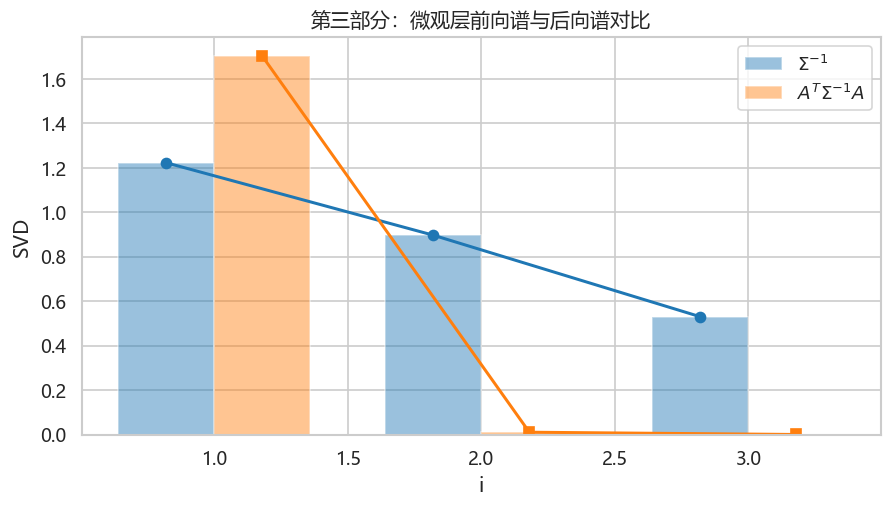

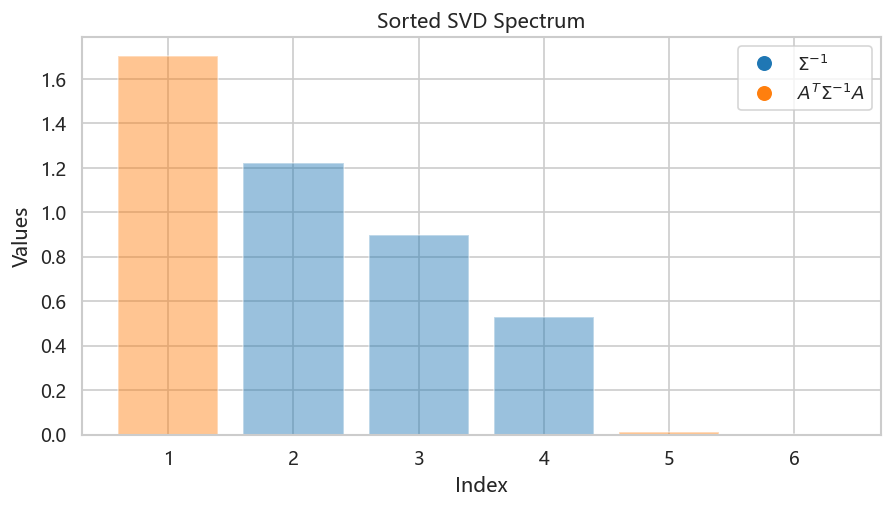

In [ ]:
metrics3_micro = compute_gis_metrics(A3_micro, Sigma3_micro, alpha=analysis_config['alpha'], eps=analysis_config['eps'])
display(pd.DataFrame({'metric': ['Gamma','log_Gamma','J_alpha','D','N'], 'value': [metrics3_micro['Gamma'], metrics3_micro['log_Gamma'], metrics3_micro['J_alpha'], metrics3_micro['D'], metrics3_micro['N']]}))
plot_dual_gis_spectrum(metrics3_micro['sv_forward'], metrics3_micro['sv_backward'], '第三部分：微观层前向谱与后向谱对比')
plot_gis_spectrum(metrics3_micro['sv_forward'], metrics3_micro['sv_backward'], title='Sorted SVD Spectrum', horizontal_line_value=None)


### 3.7 宏观维度选择与 W 的构造

宏观维度 $r$ 与粗粒化矩阵 $W$ 直接由真值微观层 $\left(A_o,\Sigma_o\right)$ 决定。

这一部分采用完整的两步 SVD 法来构造粗粒化矩阵 $W$，其核心思想是同时综合确定性与非简并性两类结构信息，而不是只依赖某一个矩阵单独给出宏观方向。

具体步骤如下：

1. 分别对$A_o^\top \Sigma_o^{-1} A_o$和$\Sigma_o^{-1}$做 SVD 分解，得到$U_{\mathrm{non\text{-}deg}},\; S_{\mathrm{non\text{-}deg}}\qquad \text{和} \qquad U_{\mathrm{det}},\; S_{\mathrm{det}}.$

2. 将两组奇异值$S_{\mathrm{non\text{-}deg}},\; S_{\mathrm{det}}$合并在一起，并按降序排列，得到统一的奇异值集合$S_{\mathrm{all}}.$

3. 按照阈值 $\epsilon$ 对 $S_{\mathrm{all}}$ 做第一次截断，保留对应的主方向与奇异值，得到截断后的方向矩阵与奇异值矩阵$\bar U,\; \bar S.$

4. 对加权后的组合矩阵$\bar U \bar S$再次做 SVD 分解，得到$U_2,\; S_2.$

5. 再按照同一阈值 $\epsilon$ 做第二次截断，最终得到粗粒化矩阵$W = \bar U_2^\top.$

因此，这里得到的 $W$ 不是简单由前向谱或后向谱单独决定，而是由确定性与非简并性两类主方向在统一排序、截断和再次分解之后共同给出的宏观表示。


也就是说，这里的粗粒化不再依赖经验拟合结果，而是依赖理论真值矩阵本身的谱结构。

在线性粗粒化情形下，宏观变量定义为
$
z_t = W o_t.
$

因此，这一步得到的是“真值动力学与真值观测层噪音下的候选宏观方向”，更适合作为方法正确性的验证对象。



第三部分第二次截断后的宏观维度 r = 1


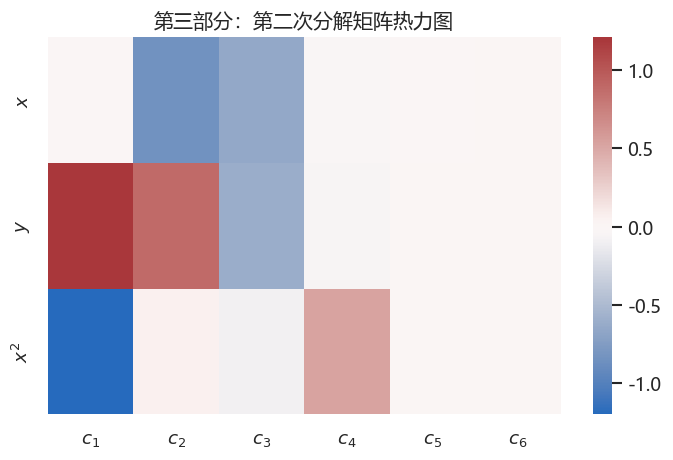

,singular_index,singular_value
0,1,1.911568
1,2,1.085014
2,3,0.803207


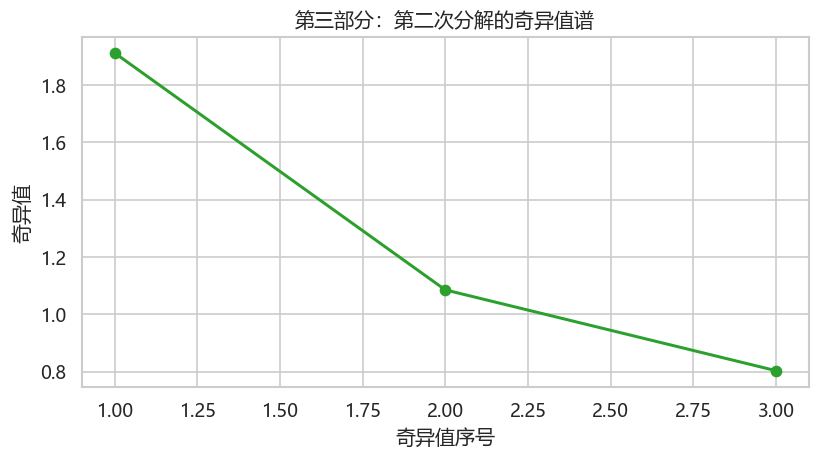

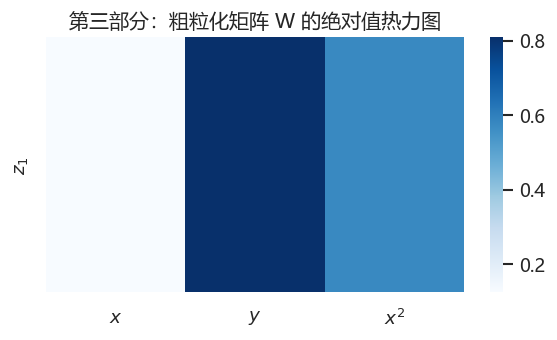

[[-0.12512679  0.80890653 -0.57446803]]


In [48]:
requested_r3 = analysis_config.get('manual_r', None)
w_result3 = build_w_from_svd(
    A3_micro,
    Sigma3_micro,
    r=requested_r3,
    alpha=analysis_config['alpha'],
    eps=analysis_config['eps'],
    mode='two_stage',
)
W3 = w_result3['W']
r3 = w_result3['r']
rank_meta3 = w_result3['stage_info']
macro_names_3 = [f'$z_{i+1}$' for i in range(r3)]
print('第三部分第二次截断后的宏观维度 r =', r3)

plot_matrix_heatmap(
    w_result3['basis_info']['weighted_matrix'],
    '第三部分：第二次分解矩阵热力图',
    row_labels=feature_names_3,
    col_labels=[f'$c_{i+1}$' for i in range(w_result3['basis_info']['weighted_matrix'].shape[1])],
    center=0.0,
    figsize=(6, 4),
    cmap='vlag',
)

sv_stage2_3 = w_result3['sv_info']['sv_stage2']
display(pd.DataFrame({'singular_index': np.arange(1, len(sv_stage2_3) + 1), 'singular_value': sv_stage2_3}))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, len(sv_stage2_3) + 1), sv_stage2_3, marker='o', color='tab:green', linewidth=1.8)
ax.set_title('第三部分：第二次分解的奇异值谱')
ax.set_xlabel('奇异值序号')
ax.set_ylabel('奇异值')
plt.tight_layout(); plt.show()
plot_matrix_heatmap(np.abs(W3), '第三部分：粗粒化矩阵 W 的绝对值热力图', row_labels=macro_names_3, col_labels=feature_names_3, center=None, figsize=(5, 3), cmap='Blues')
print(W3)


### 3.8 宏观数据生成
宏观变量由
$
\mathbf{z}_t = W \mathbf{o}_t
$
给出。得到宏观数据后，就可以把同一套配对、拟合和预测过程平移到宏观层。下面先生成宏观时间序列，并构造宏观层的时间配对样本。这里参与映射的是带噪观测层数据，因此宏观数据本身也会继承噪音 realization 带来的波动；但宏观变量的定义，并不是由经验拟合给出的，而是由真值 $A_o,\Sigma_o$ 导出的。



In [49]:
z3 = apply_coarse_graining(W3, obs_part3)
Z_now_3, Z_next_3 = prepare_time_pairs(z3, tau=analysis_config['tau'], burn_in=0, stride=1)
print('第三部分宏观数据形状:', z3.shape)
print('第三部分宏观配对样本形状:', Z_now_3.shape, Z_next_3.shape)


第三部分宏观数据形状: (601, 1)
第三部分宏观配对样本形状: (600, 1) (600, 1)


### 3.9 宏观层真值矩阵与真值协方差

宏观层直接由微观层真值与粗粒化矩阵给出：
$$
A_z = W A_o W^\top,
\qquad
\Sigma_z = W \Sigma_o W^\top.
$$

这样宏观层也保持在“真值参数已知”的验证语境下，从而保证宏微观比较完全建立在同一套理论参数之上。



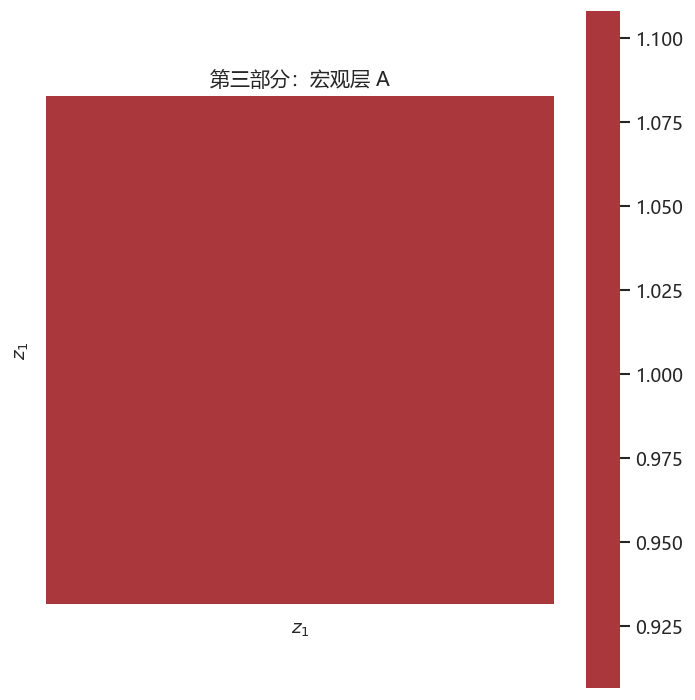

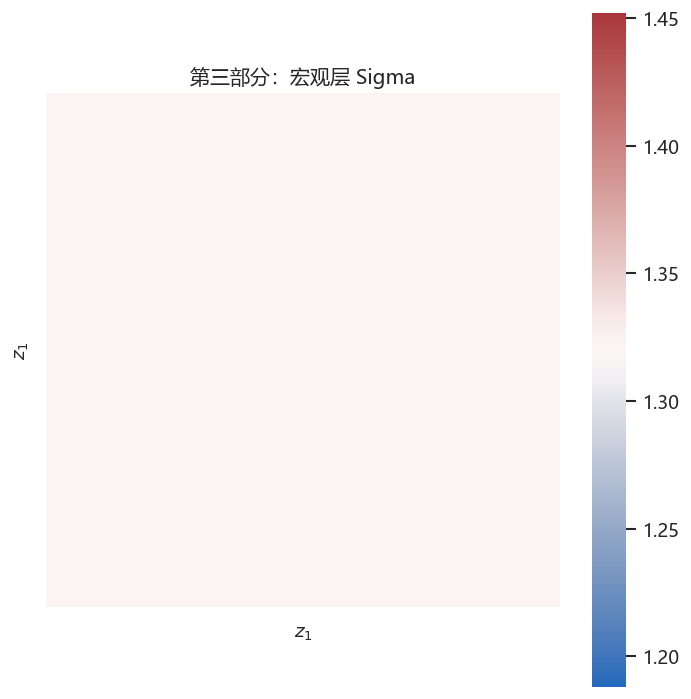

In [50]:
A3_macro = W3 @ A3_micro @ W3.T
Sigma3_macro = W3 @ Sigma3_micro @ W3.T
fit3_macro = {
    'A': A3_macro,
    'Sigma': Sigma3_macro,
    'source': 'projected_true_A_and_projected_observation_noise_covariance',
}
plot_matrix_heatmap(A3_macro, '第三部分：宏观层 A', row_labels=macro_names_3, col_labels=macro_names_3, label_step=1)
plot_matrix_heatmap(Sigma3_macro, '第三部分：宏观层 Sigma', row_labels=macro_names_3, col_labels=macro_names_3, center=None, label_step=1)


### 3.10 宏观层预测与误差

在宏观层上，预测同样直接基于真值 $A_z$ 进行：
$$
\hat z_{t+\tau|t}=A_z z_t,
\qquad
\hat z_{t+k\tau|t}=A_z^k z_t.
$$

这里的误差仍然是数据层误差，其作用是检验：在真值宏观动力学已知的情况下，宏观表示是否能够稳定跟随真实宏观数据的主要变化。



,horizon,mean_error
0,1,2.673712
1,3,2.868929
2,5,3.315378


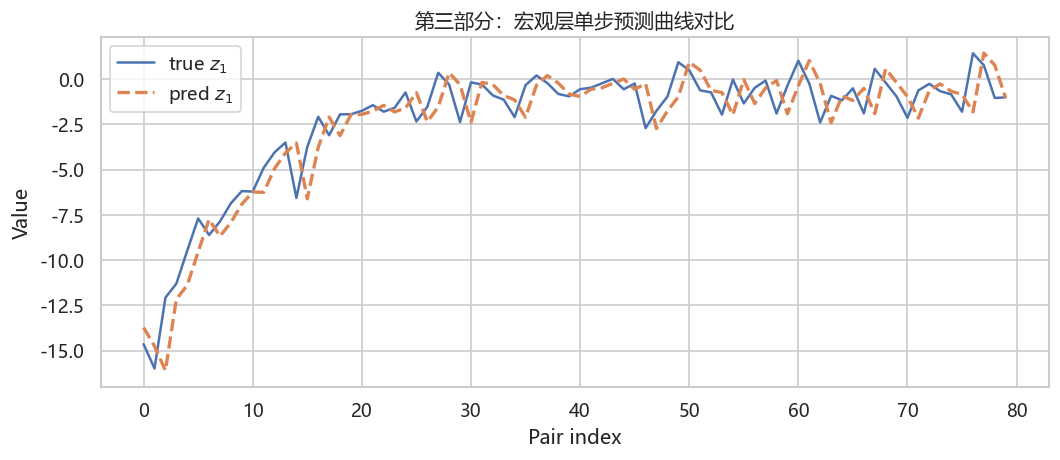

In [51]:
errors3_macro = compute_prediction_errors(A3_macro, z3, tau=analysis_config['tau'], horizons=analysis_config['horizons'])
display(pd.DataFrame({'horizon': list(errors3_macro.keys()), 'mean_error': [errors3_macro[h]['mean_error'] for h in errors3_macro.keys()]}))
pred1_macro, target1_macro = errors3_macro[1]['predictions'], errors3_macro[1]['targets']
plt.figure(figsize=(9,4))
for idx, name in enumerate(macro_names_3):
    plt.plot(np.arange(len(pred1_macro[:80])), target1_macro[:80, idx], label=f'true {name}')
    plt.plot(np.arange(len(pred1_macro[:80])), pred1_macro[:80, idx], '--', linewidth=2.0, label=f'pred {name}')
plt.title('第三部分：宏观层单步预测曲线对比')
plt.xlabel('Pair index')
plt.ylabel('Value')
plt.legend()
plt.tight_layout(); plt.show()


### 3.11 宏观层 GIS 指标
宏观层同样要计算 `Gamma`、`log Gamma`、`J`、`D`、`N`。在谱图上也同时展示前向矩阵 `\Sigma_z^{-1}` 和后向矩阵 `A_z^\top \Sigma_z^{-1}A_z` 的谱，这样可以和微观层保持同一可视化标准。


,metric,value
0,Gamma,0.873575
1,log_Gamma,-0.135162
2,J_alpha,-0.135162
3,D,-0.277634
4,N,-0.263013


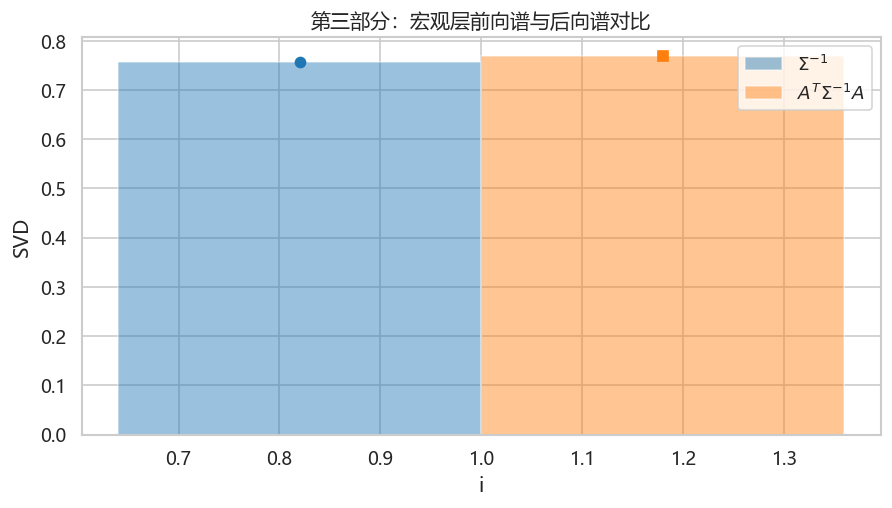

In [52]:
metrics3_macro = compute_gis_metrics(A3_macro, Sigma3_macro, alpha=analysis_config['alpha'], eps=analysis_config['eps'])
display(pd.DataFrame({'metric': ['Gamma','log_Gamma','J_alpha','D','N'], 'value': [metrics3_macro['Gamma'], metrics3_macro['log_Gamma'], metrics3_macro['J_alpha'], metrics3_macro['D'], metrics3_macro['N']]}))
plot_dual_gis_spectrum(metrics3_macro['sv_forward'], metrics3_macro['sv_backward'], '第三部分：宏观层前向谱与后向谱对比')


### 3.12 CE 值与宏微观曲线对比

在本部分中，
$$
CE = J_{\alpha,z} - J_{\alpha,o}
$$
完全由真值矩阵与真值协方差决定，因此它是一个“理论真值下的结构增益”，而不是经验估计值。与此同时，宏微观曲线仍然来自具体噪音 realization 下的数据，因此曲线图主要用于展示和验证，而不是定义 `CE` 本身。

也就是说，本部分同时保留两条线索：
- 理论层：由真值 $A,\Sigma$ 给出 `CE` 和结构指标；
- 数据层：由带噪轨迹给出宏微观曲线与预测误差。


第三部分 CE = 1.124272448887589


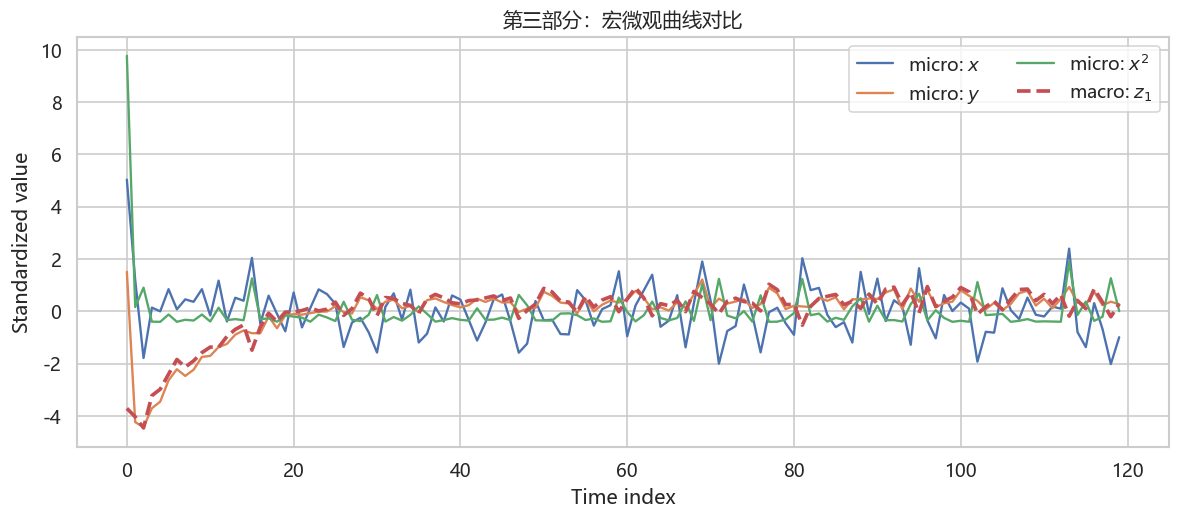

In [53]:
ce3 = compute_ce_from_micro_macro(metrics3_micro, metrics3_macro)
print('第三部分 CE =', ce3['CE'])
plt.figure(figsize=(10,4.5))
for idx, name in enumerate(feature_names_3):
    plt.plot(np.arange(120), standardize_for_plot(obs_part3[:120, idx]), linewidth=1.4, label=f'micro: {name}')
for idx, name in enumerate(macro_names_3):
    plt.plot(np.arange(120), standardize_for_plot(z3[:120, idx]), '--', linewidth=2.2, label=f'macro: {name}')
plt.title('第三部分：宏微观曲线对比')
plt.xlabel('Time index')
plt.ylabel('Standardized value')
plt.legend(ncol=2)
plt.tight_layout(); plt.show()


### 3.13 结果汇总

最后把本次实验的真值参数、宏微观真值矩阵、真值协方差、预测误差和 `CE` 汇总下来。由于当前实验的目的是验证方法正确性，并且 $A,\Sigma$ 都由真值直接给定，因此这一部分不再引入多次随机种子重复实验，也不再对结果做平均。当前保留单次噪音 realization 下的数据展示即可。


In [54]:
summary3_dict, summary3_row = summarize_pipeline_results(
    config={'experiment_name': analysis_config['experiment_name'], 'tau': analysis_config['tau'], 'delta': analysis_config['delta'], 'alpha': analysis_config['alpha'], 'noise_scale': analysis_config['noise_scale']},
    micro_fit=fit3_micro,
    macro_fit=fit3_macro,
    micro_metrics=metrics3_micro,
    macro_metrics=metrics3_macro,
    prediction_results={'micro_errors': errors3_micro, 'macro_errors': errors3_macro},
    ce_result=ce3,
    extra={'W': W3, 'rank_meta': rank_meta3, 'observation_noise_covariance': Sigma3_micro},
)
display(pd.DataFrame([summary3_row]))


,experiment_name,tau,alpha,delta,noise_scale,micro_dim,macro_dim,micro_J_alpha,macro_J_alpha,micro_D,...,micro_N,macro_N,micro_log_Gamma,macro_log_Gamma,CE,delta_D,delta_N,delta_log_Gamma,micro_E1,macro_E1
0,exp_ana_gis_part3,1,1.0,None,1,3,1,-1.259434,-0.135162,-0.543489,...,-14.569721,-0.263013,-3.778302,-0.135162,1.124272,0.265855,14.306708,3.643141,7.882439,2.673712


## 第四部分：step2 系统下 SVD 与 EVD 的对比

### 4.1 step2 系统与本部分目标
`step2` 系统包含明显的非正交混合作用，因此非常适合比较奇异值分解与特征值分解在宏观方向提取上的差异。直接从 `step2` 系统的解析动力学矩阵出发，对其进行 SVD 与 EVD 的矩阵级比较。也就是说，本部分的目标不是从数据拟合出动力学矩阵，而是在已知真值矩阵的前提下，比较奇异值分解与特征值分解在宏观方向提取上的差异。



In [55]:
def step2_local(x, y, a=0.8, coupling=10.0):
    return a * x + coupling * (y ** 2), a * y

step2_config = {'experiment_name': 'exp_ana_gis_part4_step2', 'initial_state': [0.2, 0.45], 'steps': 220, 'dt': 1.0, 'tau': 1, 'delta': None, 'alpha': 1.0, 'noise_scale': 0.1, 'noise_seed': 7, 'eps': 1e-10, 'ridge': 1e-10, 'manual_r': 1, 'horizons': (1, 3, 5)}
step2_sim = simulate_discrete_system(step2_local, step2_config['initial_state'], steps=step2_config['steps'], system_kwargs={'a': 0.8, 'coupling': 10.0}, dt=step2_config['dt'])
step2_clean, step2_time = step2_sim['trajectories'][0], step2_sim['time_grid']
step2_noisy = add_gaussian_noise(step2_clean, noise_scale=step2_config['noise_scale'], cov=None, random_state=step2_config['noise_seed'])['noisy_data']


### 4.2 step2 系统数据轨迹与相图
这里先画出 `step2` 系统的相图。这个图的意义在于：后面的 SVD / EVD 差异不只是一组数值差异，还能和轨迹在几何上的主伸缩方向联系起来。


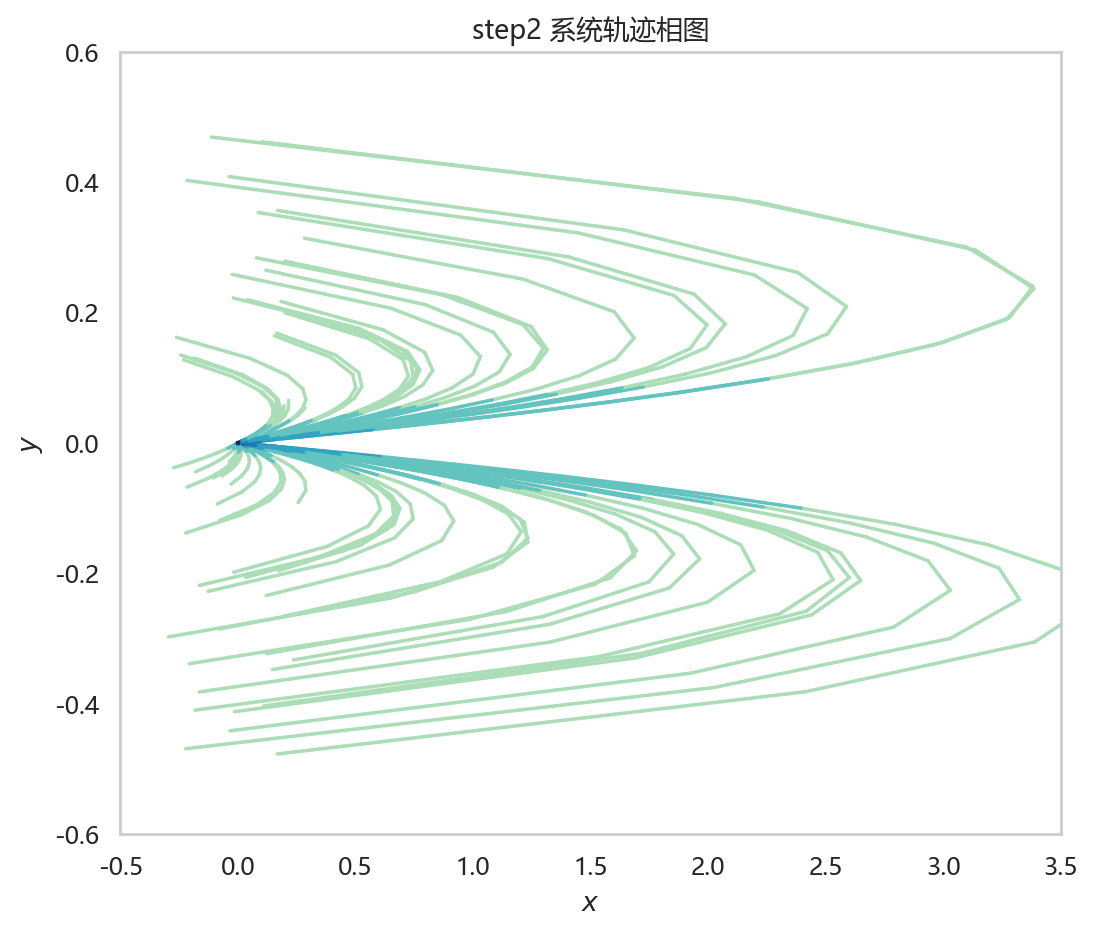

In [56]:
fig, ax = plt.subplots(figsize=(7, 6), dpi=160)
rng = np.random.default_rng(42)
initial_points = np.vstack([rng.uniform(-0.3, 0.3, 60), rng.uniform(-0.5, 0.5, 60)]).T
custom_cmap = ListedColormap(plt.cm.YlGnBu(np.linspace(0.3, 0.95, 6)))
for x0, y0 in initial_points:
    traj = simulate_discrete_system(step2_local, [x0, y0], steps=120, system_kwargs={'a': 0.8, 'coupling': 10.0}, dt=1.0)['trajectories'][0]
    points = traj.reshape(-1, 1, 2); segments = np.concatenate([points[:-1], points[1:]], axis=1); color_idx = np.arange(len(segments)); color_idx[np.where(color_idx > 40)] = 40
    lc = LineCollection(segments, cmap=custom_cmap); lc.set_array(color_idx); lc.set_linewidth(1.6); lc.set_capstyle('round'); ax.add_collection(lc)
ax.set_xlabel('$x$'); ax.set_ylabel('$y$'); ax.set_title('step2 系统轨迹相图'); ax.set_xlim([-0.5, 3.5]); ax.set_ylim([-0.6, 0.6]); ax.grid(False); plt.tight_layout(); plt.show()


### 4.3 标准 SVD 路线

下面直接对 `step2` 系统的解析矩阵 $A$ 做奇异值分解：
$$
A = U \Sigma_A V^\top.
$$
然后使用左奇异向量构造粗粒化矩阵，并进一步得到宏观矩阵与宏观曲线。这里的逻辑与第二部分一致，重点是考察 SVD 路线抽取出的主方向是否与系统的主要动力学模式一致。



In [57]:
obs_step2 = observable_step2(step2_noisy, mode='default')
A_step2_micro = np.array([
    [0.8, 0.0, 10.0],
    [0.0, 0.8, 0.0],
    [0.0, 0.0, 0.64],
], dtype=float)
U_step2, S_step2, Vt_step2 = np.linalg.svd(A_step2_micro, full_matrices=False)
step2_svd_gamma = compute_gamma_ce_metrics(S_step2, alpha=step2_config['alpha'], manual_r=step2_config['manual_r'], eps=step2_config['eps'])
r_step2 = int(step2_config['manual_r'])
W_step2_svd = U_step2[:, :r_step2].T
svd_macro_step2 = apply_coarse_graining(W_step2_svd, obs_step2)
A_step2_svd_macro = W_step2_svd @ A_step2_micro @ W_step2_svd.T
print('step2 - SVD 路线 CE =', step2_svd_gamma['delta_gamma_manual_r'])


step2 - SVD 路线 CE = 6.417831296421012


### 4.4 EVD 路线

这里保持同一个解析矩阵 $A$，只把分解方式从 SVD 换成 EVD。若
$$
A w_i = \lambda_i w_i,
$$
则根据特征值与特征向量的排序规则选出宏观方向，并构造对应的粗粒化矩阵。对于复特征值，谱比较时统一取模长；若特征值为负，也统一按绝对值排序比较。



In [58]:
step2_evd_pack = build_w_from_evd(A_step2_micro, r=r_step2, mode='eig_abs')
W_step2_evd = step2_evd_pack['W']
eig_abs_step2 = np.sort(np.abs(np.asarray(step2_evd_pack['eigvals'])))[::-1]
step2_evd_gamma = compute_gamma_ce_metrics(eig_abs_step2, alpha=step2_config['alpha'], manual_r=step2_config['manual_r'], eps=step2_config['eps'])
evd_macro_step2 = apply_coarse_graining(W_step2_evd, obs_step2)
A_step2_evd_macro = W_step2_evd @ A_step2_micro @ W_step2_evd.T
print('step2 - EVD 路线 CE =', step2_evd_gamma['delta_gamma_manual_r'])


step2 - EVD 路线 CE = 0.053333333333333344


### 4.5 奇异值谱与特征值谱的对比
下面把 `step2` 系统微观层矩阵的奇异值谱与特征值谱放在同一张图中比较。这个图主要回答的问题是：两种分解强调的主方向是否一致，还是它们实际上在看动力学矩阵的不同侧面。


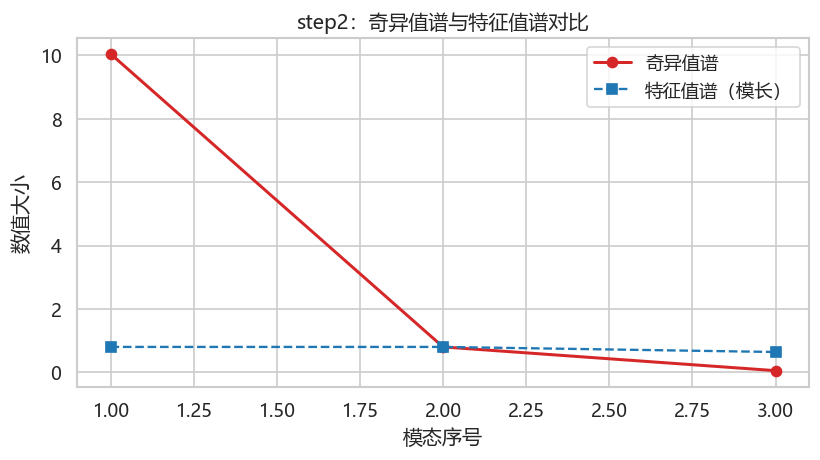

In [59]:
sv_step2 = S_step2
plt.figure(figsize=(7,4))
plt.plot(np.arange(1, len(sv_step2)+1), sv_step2, marker='o', linewidth=1.8, label='奇异值谱', color='tab:red')
plt.plot(np.arange(1, len(eig_abs_step2)+1), eig_abs_step2, marker='s', linewidth=1.4, linestyle='--', label='特征值谱（模长）', color='tab:blue')
plt.title('step2：奇异值谱与特征值谱对比')
plt.xlabel('模态序号')
plt.ylabel('数值大小')
plt.legend(); plt.tight_layout(); plt.show()


### 4.6 两种情况下的粗粒化矩阵对比
粗粒化矩阵反映了宏观变量到底是由哪些观测变量组合而成。下面分别画出 SVD 与 EVD 路线得到的 `W`，用热力图观察两种方法提取出的宏观方向是否一致。


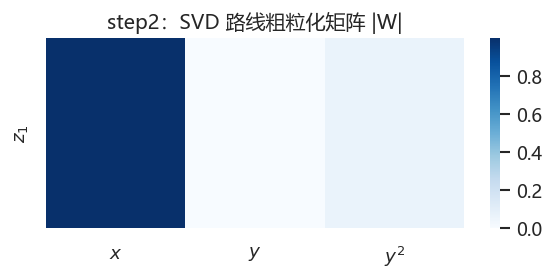

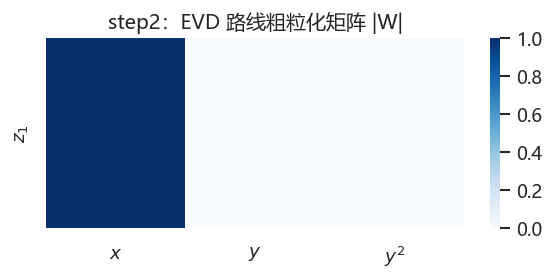

In [60]:
step2_feature_names = ['$x$', '$y$', '$y^2$']
step2_macro_names = [f'$z_{i+1}$' for i in range(r_step2)]
plot_matrix_heatmap(np.abs(W_step2_svd), 'step2：SVD 路线粗粒化矩阵 |W|', row_labels=step2_macro_names, col_labels=step2_feature_names, center=None, figsize=(5, 2.5), cmap='Blues')
plot_matrix_heatmap(np.abs(W_step2_evd), 'step2：EVD 路线粗粒化矩阵 |W|', row_labels=step2_macro_names, col_labels=step2_feature_names, center=None, figsize=(5, 2.5), cmap='Blues')


### 4.7 两种方法下的宏微观曲线对比
这里把微观曲线、SVD 宏观曲线和 EVD 宏观曲线放在同一张图上。为避免曲线重合后看不清，微观层使用实线，SVD 宏观使用虚线，EVD 宏观使用点划线，并对每条曲线做标准化处理。


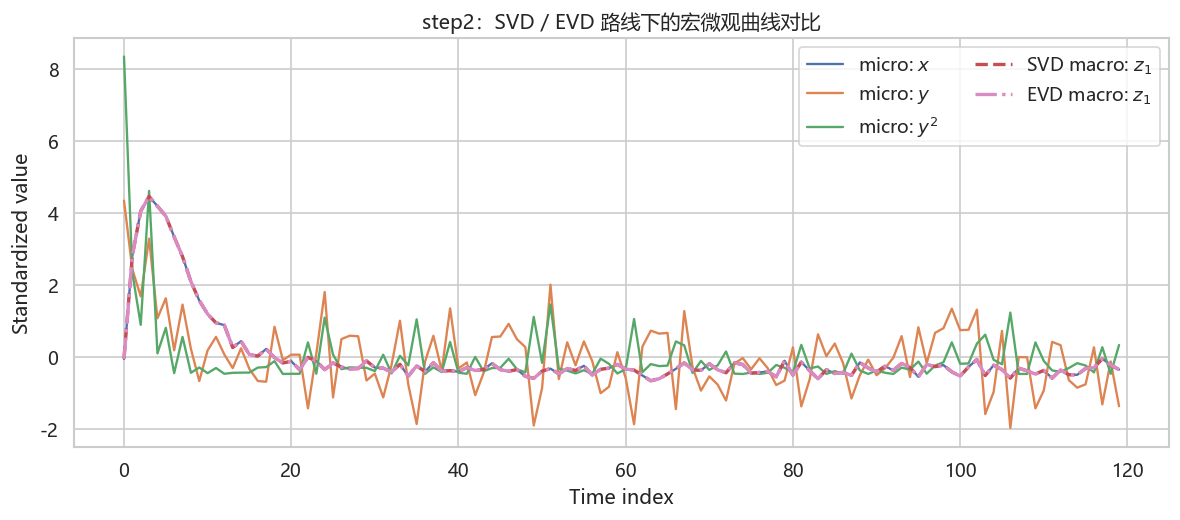

In [61]:
plt.figure(figsize=(10,4.5))
for idx, name in enumerate(step2_feature_names):
    plt.plot(np.arange(120), standardize_for_plot(obs_step2[:120, idx]), linewidth=1.4, label=f'micro: {name}')
for idx in range(svd_macro_step2.shape[1]):
    plt.plot(np.arange(120), standardize_for_plot(svd_macro_step2[:120, idx]), '--', linewidth=2.0, color=f'C{idx+3}', label=f'SVD macro: $z_{idx+1}$')
for idx in range(evd_macro_step2.shape[1]):
    plt.plot(np.arange(120), standardize_for_plot(evd_macro_step2[:120, idx]), '-.', linewidth=2.0, color=f'C{idx+6}', label=f'EVD macro: $z_{idx+1}$')
plt.title('step2：SVD / EVD 路线下的宏微观曲线对比')
plt.xlabel('Time index')
plt.ylabel('Standardized value')
plt.legend(ncol=2)
plt.tight_layout(); plt.show()


### 4.8 核心数值比较与结论
最后汇总 `step2` 系统下 SVD 与 EVD 两条路线的核心数值，包括 `CE`、宏微观维度平均效率和对数近似可逆性。这样可以把“图像上的差异”和“指标上的差异”放在一起读。


In [62]:
display(pd.DataFrame([
    {
        'method': 'SVD',
        'micro_channel_mean': step2_svd_gamma['gamma_alpha_K'],
        'selected_r': step2_svd_gamma['selected_r'],
        'macro_top_singular': float(np.linalg.svd(A_step2_svd_macro, compute_uv=False)[0]),
        'CE': step2_svd_gamma['delta_gamma_manual_r'],
    },
    {
        'method': 'EVD',
        'micro_channel_mean': step2_evd_gamma['gamma_alpha_K'],
        'selected_r': step2_evd_gamma['selected_r'],
        'macro_top_singular': float(np.linalg.svd(A_step2_evd_macro, compute_uv=False)[0]),
        'CE': step2_evd_gamma['delta_gamma_manual_r'],
    }
]))


,method,micro_channel_mean,selected_r,macro_top_singular,CE
0,SVD,3.634383,1,1.43274,6.417831
1,EVD,0.746667,1,0.80000,0.053333


## 第五部分：结尾统一摘要

### 5.1 统一结论
最后用少量核心数值把四个部分串起来：第一部分提供参数与谱的直观背景，第二部分验证矩阵层面的宏微比较逻辑，第三部分给出含噪数据下的完整 `GIS` 主流程，第四部分则展示在 `step2` 系统上 SVD 与 EVD 会如何导出不同的宏观方向与 `CE` 结果。


In [63]:
final_summary = {
    'part2_direct_matrix_ce': direct_ce['CE'],
    'part3_noisy_pipeline_ce': ce3['CE'],
    'part4_step2_svd_ce': step2_svd_gamma['delta_gamma_manual_r'],
    'part4_step2_evd_ce': step2_evd_gamma['delta_gamma_manual_r'],
}
print('统一摘要：')
for key, value in final_summary.items():
    print(f'{key}: {value:.6f}')
display(pd.DataFrame([
    {'part': '解析矩阵 A', 'CE': direct_ce['CE']},
    {'part': '含噪数据完整流程', 'CE': ce3['CE']},
    {'part': 'step2 - SVD', 'CE': step2_svd_gamma['delta_gamma_manual_r']},
    {'part': 'step2 - EVD', 'CE': step2_evd_gamma['delta_gamma_manual_r']},
]))


统一摘要：
part2_direct_matrix_ce: 0.808137
part3_noisy_pipeline_ce: 1.124272
part4_step2_svd_ce: 6.417831
part4_step2_evd_ce: 0.053333


,part,CE
0,解析矩阵 A,0.808137
1,含噪数据完整流程,1.124272
2,step2 - SVD,6.417831
3,step2 - EVD,0.053333
